# 时序差分算法TD

DP算法往往要求马尔科夫决策过程是已经知道的， 但是往往Agent 和 环境交互的那个马尔科夫状态转移矩阵是无法获得的，即公式里的P未知

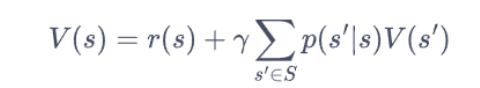

在无法获知的情况，一种是使用蒙特卡洛的方式不断对每个V(s)进行逼近估计，在01小节估计过

# TD = MC + TD

时序差分是一种用来估计一个策略的价值函数的方法，它结合了蒙特卡洛和动态规划算法的思想。时序差分方法和蒙特卡洛的相似之处在于可以从样本数据中学习，不需要事先知道环境；和动态规划的相似之处在于根据贝尔曼方程的思想，利用后续状态的价值估计来更新当前状态的价值估计。

态的价值估计来更新当前状态的价值估计。回顾一下蒙特卡洛方法对价值函数的增量更新方式：

$$
V(s_t) \leftarrow V(s_t) + \alpha [G_t - V(s_t)]
$$

这里我们将 3.5 节的 $\frac{1}{N(s)}$ 替换成了 $\alpha$，表示对价值估计更新的步长。可以将 $\alpha$ 取为一个常数，此时更新方式不再像蒙特卡洛方法那样严格地取期望。蒙特卡洛方法必须要等整个序列结束之后才能计算得到这一次的回报 $G_t$，而时序差分方法只需要当前步结束即可进行计算。具体来说，时序差分算法用当前获得的奖励加上下一个状态的价值估计来作为在当前状态会获得的回报，即：

$$
V(s_t) \leftarrow V(s_t) + \alpha [r_t + \gamma V(s_{t+1}) - V(s_t)]
$$

其中 $R_t + \gamma V(s_{t+1}) - V(s_t)$ 通常被称为**时序差分（temporal difference，TD）误差（error）**，时序差分算法将其与步长的乘积作为状态价值的更新量。可以用 $r_t + \gamma V(s_{t+1})$ 来代替 $G_t$ 的原因是：

$$
\begin{aligned}
V_\pi(s)
&= \mathbb{E}_\pi [G_t \mid S_t = s] \\
&= \mathbb{E}_\pi \left[\sum_{k=0}^{\infty} \gamma^k R_{t+k} \mid S_t = s\right] \\
&= \mathbb{E}_\pi \left[R_t + \gamma \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s\right] \\
&= \mathbb{E}_\pi [R_t + \gamma V_\pi(S_{t+1}) \mid S_t = s]
\end{aligned}
$$

因此蒙特卡洛方法将上式第一行作为更新的目标，而时序差分算法将上式最后一行作为更新的目标。于是，在用策略和环境交互时，每采样一步，我们就可以用时序差分算法来更新状态价值估计。时序差分算法用到了 $V(s_{t+1})$ 的估计值，可以证明它最终收敛到策略 $\pi$ 的价值函数，我们在此不对此进行展开说明。
